**<h1 align="center">Facial Age Progression Using Residual Conditional GANs with Active Sample Pruning on the CACD Dataset (Code Implementation)</h1>**

**Student Name: Jessie Ma\
Student Number: 501274167**


Setup and Dependency Imports:
This cell imports essential libraries for PyTorch, path management, image manipulation, metric evaluation (SSIM/RMSE), and loss visualization.

In [43]:
import os
import glob
from PIL import Image
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error
import matplotlib.pyplot as plt
from google.colab import drive
import zipfile

# Mount Google Drive in Colab
drive.mount('/content/drive')

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda


Active Pruning Dataset Pipeline and 10-Year Timeline Pairing:
Handles dataset pre-processing with active sample pruning during training mode to discard redundant photos without structural variance. In test mode, it identifies 10-year paired timelines (e.g., 2004 vs 2013) for exact ground-truth comparison.

In [44]:
class CACDPrunedDataset(Dataset):
    def __init__(self, root_dir, transform=None, mode='train', variance_threshold=0.01):
        self.root_dir = root_dir
        self.transform = transform
        self.mode = mode
        self.samples = []

        # Search recursively for all image files
        all_files = glob.glob(os.path.join(root_dir, "**", "*.jpg"), recursive=True) + \
                    glob.glob(os.path.join(root_dir, "**", "*.jpeg"), recursive=True) + \
                    glob.glob(os.path.join(root_dir, "**", "*.png"), recursive=True)

        identity_dict = {}
        for filepath in all_files:
            filename = os.path.basename(filepath)
            identity = os.path.basename(os.path.dirname(filepath)) # Parent folder (e.g., '50Cent')

            # --- PARSE AGE FROM FILENAME ([age]_[celebrity]_[num].jpg) ---
            parts = filename.split('_')
            age = None
            if len(parts) >= 1 and parts[0].isdigit():
                age = int(parts[0])

            if age is not None:
                if identity not in identity_dict:
                    identity_dict[identity] = []
                identity_dict[identity].append({'path': filepath, 'age': age})

        if self.mode == 'train':
            # Active Sample Pruning Pipeline
            for identity, items in identity_dict.items():
                seen_variances = []
                for item in items:
                    try:
                        img = Image.open(item['path']).convert('RGB')
                        var = np.var(np.array(img) / 255.0)

                        if any(abs(var - sv) < variance_threshold for sv in seen_variances):
                            continue

                        seen_variances.append(var)
                        self.samples.append(item)
                    except Exception:
                        continue

        elif self.mode == 'test':
            # --- STRICT 10-YEAR AGE GAP PAIRING ---
            for identity, items in identity_dict.items():
                items_by_age = {item['age']: item for item in items}

                # Look for exact pairs separated by 9, 10, or 11 years of age difference
                for age in items_by_age:
                    target_age = None
                    if (age + 10) in items_by_age:
                        target_age = age + 10
                    elif (age + 9) in items_by_age:
                        target_age = age + 9
                    elif (age + 11) in items_by_age:
                        target_age = age + 11

                    if target_age is not None:
                        self.samples.append({
                            'source': items_by_age[age],
                            'target': items_by_age[target_age],
                            'age_gap': target_age - age
                        })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.mode == 'train':
            item = self.samples[idx]
            img = Image.open(item['path']).convert('RGB')
            if self.transform:
                img = self.transform(img)
            age_group = min(max((item['age'] - 14) // 10, 0), 4)
            return img, age_group
        else:
            pair = self.samples[idx]
            src_img = Image.open(pair['source']['path']).convert('RGB')
            tgt_img = Image.open(pair['target']['path']).convert('RGB')
            if self.transform:
                src_img = self.transform(src_img)
                tgt_img = self.transform(tgt_img)
            tgt_age_group = min(max((pair['target']['age'] - 14) // 10, 0), 4)
            age_gap = pair['age_gap']
            return src_img, tgt_img, tgt_age_group, age_gap

Residual cGAN Model Architecture:
Defines the Residual Generator and Discriminator. The generator outputs only the residual aging map (delta), adding it to the input image for computational acceleration.

In [45]:
class ResidualGenerator(nn.Module):
    def __init__(self, num_classes=5, embed_dim=64):
        super(ResidualGenerator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, embed_dim)

        self.enc1 = nn.Sequential(nn.Conv2d(4, 64, 4, 2, 1), nn.LeakyReLU(0.2, inplace=True))
        self.enc2 = nn.Sequential(nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, inplace=True))

        self.bottleneck = nn.Sequential(nn.Conv2d(128, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(inplace=True))

        self.dec1 = nn.Sequential(nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.dec2 = nn.Sequential(nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh())

    def forward(self, x, labels):
        emb = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        emb = emb.repeat(1, 1, x.size(2), x.size(3))
        emb_single = torch.mean(emb, dim=1, keepdim=True)

        gen_input = torch.cat([x, emb_single], dim=1)
        e1 = self.enc1(gen_input)
        e2 = self.enc2(e1)
        b = self.bottleneck(e2)
        d1 = self.dec1(b)
        residual = self.dec2(d1)

        synthetic_face = torch.clamp(x + residual, -1.0, 1.0)
        return synthetic_face, residual

class Discriminator(nn.Module):
    def __init__(self, num_classes=5):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(num_classes, 64)

        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x, labels):
        emb = self.label_emb(labels).unsqueeze(2).unsqueeze(3)
        emb = emb.repeat(1, 1, x.size(2), x.size(3))
        emb_single = torch.mean(emb, dim=1, keepdim=True)

        disc_input = torch.cat([x, emb_single], dim=1)
        return self.model(disc_input)

Training Phase Loop & Loss Tracking:
Trains the cGAN using the pruned dataset while tracking generator and discriminator loss values per epoch.

In [46]:
# Path to zip file in Google Drive
zip_path = "/content/drive/MyDrive/EE8204_Project/CACD Dataset.zip"
extract_dir = "/content/cacd_unzipped"

# Unzip the Dataset to Colab Local Storage
if os.path.exists(zip_path):
    if not os.path.exists(extract_dir):
        print(f"Unzipping dataset from Drive to local Colab storage... (This takes ~1-2 minutes)")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Unzipping complete!\n")
    else:
        print("Dataset already unzipped in local session.\n")
else:
    print(f"ERROR: Could not find '{zip_path}' in your Google Drive.")

# Target the second nested 'cacd_split' folder where celebrity subfolders live
dataset_folder_path = os.path.join(extract_dir, "cacd_split", "cacd_split")

# Fallback path check if zip structure extracts with capitalization
if not os.path.exists(dataset_folder_path):
    dataset_folder_path = os.path.join(extract_dir, "CACD Dataset", "cacd_split", "cacd_split")

# Preprocessing Transforms
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Initialize Network Models, Loss Functions, and Optimizers
generator = ResidualGenerator().to(device)
discriminator = Discriminator().to(device)

criterion_GAN = nn.BCELoss()
criterion_L1 = nn.L1Loss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 10
g_losses, d_losses = [], []

# Execute Training Loop
if os.path.exists(dataset_folder_path):
    print(f"Success! Found celebrity folders at:\n--> {dataset_folder_path}\n")

    train_dataset = CACDPrunedDataset(dataset_folder_path, transform=transform, mode='train')
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    print(f"Indexed and active-pruned {len(train_dataset)} training samples.")
    print("Starting Training Loop...\n")

    for epoch in range(epochs):
        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for imgs, age_labels in train_loader:
            batch_size = imgs.size(0)
            imgs, age_labels = imgs.to(device), age_labels.to(device)

            real_target = torch.ones(batch_size, 1, device=device)
            fake_target = torch.zeros(batch_size, 1, device=device)

            # -----------------
            #  Train Generator
            # -----------------
            optimizer_G.zero_grad()
            target_labels = torch.randint(0, 5, (batch_size,), device=device)
            gen_imgs, _ = generator(imgs, target_labels)

            d_pred = discriminator(gen_imgs, target_labels)
            loss_g = criterion_GAN(d_pred, real_target) + 0.1 * criterion_L1(gen_imgs, imgs)
            loss_g.backward()
            optimizer_G.step()

            # ---------------------
            #  Train Discriminator
            # ---------------------
            optimizer_D.zero_grad()
            d_real = discriminator(imgs, age_labels)
            loss_real = criterion_GAN(d_real, real_target)

            d_fake = discriminator(gen_imgs.detach(), target_labels)
            loss_fake = criterion_GAN(d_fake, fake_target)

            loss_d = (loss_real + loss_fake) / 2
            loss_d.backward()
            optimizer_D.step()

            epoch_g_loss += loss_g.item()
            epoch_d_loss += loss_d.item()

        g_losses.append(epoch_g_loss / len(train_loader))
        d_losses.append(epoch_d_loss / len(train_loader))
        print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_losses[-1]:.4f} | G Loss: {g_losses[-1]:.4f}")
else:
    print(f"Directory not found: {dataset_folder_path}")
    print("Check if the zip filename on Google Drive matches 'CACD Dataset.zip' exactly.")

Dataset already unzipped in local session.

Success! Found celebrity folders at:
--> /content/cacd_unzipped/cacd_split/cacd_split

Indexed and active-pruned 18536 training samples.
Starting Training Loop...

Epoch [1/10] | D Loss: 0.6930 | G Loss: 0.6965
Epoch [2/10] | D Loss: 0.6723 | G Loss: 0.7258
Epoch [3/10] | D Loss: 0.5903 | G Loss: 0.8557
Epoch [4/10] | D Loss: 0.5393 | G Loss: 0.9588
Epoch [5/10] | D Loss: 0.5218 | G Loss: 1.0119
Epoch [6/10] | D Loss: 0.4929 | G Loss: 1.0884
Epoch [7/10] | D Loss: 0.4922 | G Loss: 1.1164
Epoch [8/10] | D Loss: 0.4709 | G Loss: 1.1697
Epoch [9/10] | D Loss: 0.4673 | G Loss: 1.1974
Epoch [10/10] | D Loss: 0.4640 | G Loss: 1.2268


Pruning Metrics.

In [47]:
import os
import glob

# Use the dataset path already in memory (or set it manually if needed)
target_path = dataset_folder_path if 'dataset_folder_path' in locals() else "/content/cacd_unzipped/cacd_split/cacd_split"

# Count total raw images unzipped on disk
all_disk_images = glob.glob(os.path.join(target_path, "**", "*.jpg"), recursive=True) + \
                 glob.glob(os.path.join(target_path, "**", "*.jpeg"), recursive=True) + \
                 glob.glob(os.path.join(target_path, "**", "*.png"), recursive=True)

total_on_disk = len(all_disk_images)

# Get the number of images retained in your trained dataset
retained_in_training = len(train_dataset) if 'train_dataset' in locals() else 0

# Calculate pruned counts
pruned_count = total_on_disk - retained_in_training
prune_percentage = (pruned_count / total_on_disk) * 100 if total_on_disk > 0 else 0

print("================ Active Pruning Summary ================")
print(f"Total Raw Images Discovered on Disk: {total_on_disk}")
print(f"Unique Images Retained for Training: {retained_in_training}")
print(f"Redundant Images Pruned (Discarded): {pruned_count}")
print(f"Pruning Reduction Rate: {prune_percentage:.2f}%")
print("=========================================================")

================ Active Pruning Summary ================
Total Raw Images Discovered on Disk: 154915
Unique Images Retained for Training: 18536
Redundant Images Pruned (Discarded): 136379
Pruning Reduction Rate: 88.03%


Quantitative Evaluation, Visual Comparison, and Loss Plotting: Evaluates generated synthetic faces against ground-truth images taken ~10 years later. Displays visual side-by-side comparison (Input vs Generated vs Ground Truth) along with SSIM and RMSE metrics, followed by training loss curves.


Success! Found 1977 exact ~10-year age gap ground-truth pairs.
Running comprehensive evaluation with diagnostic graphs...



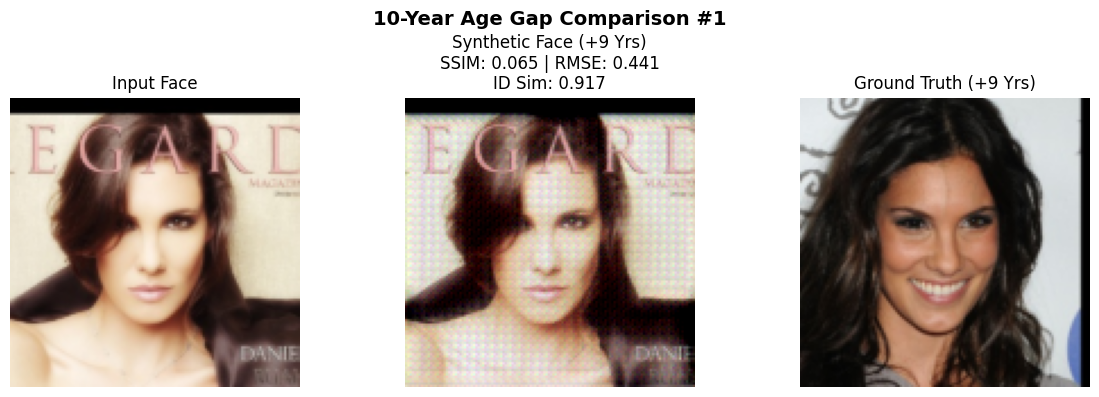

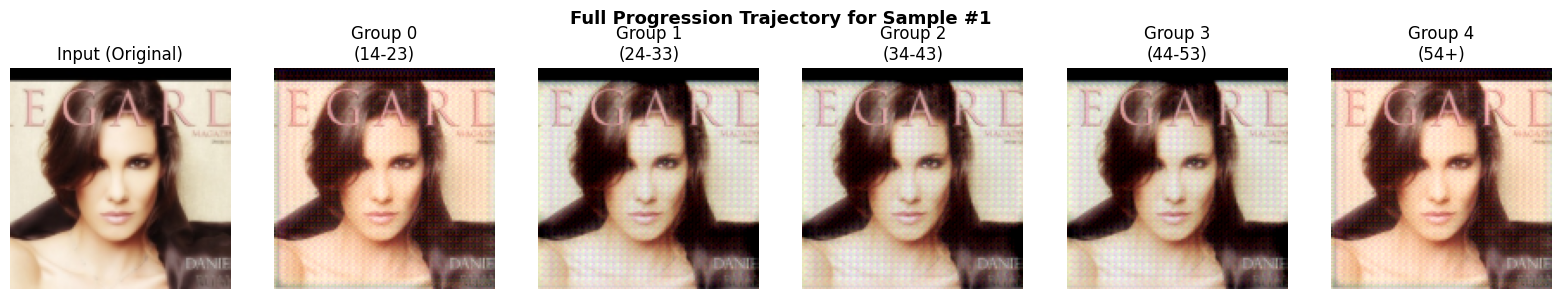

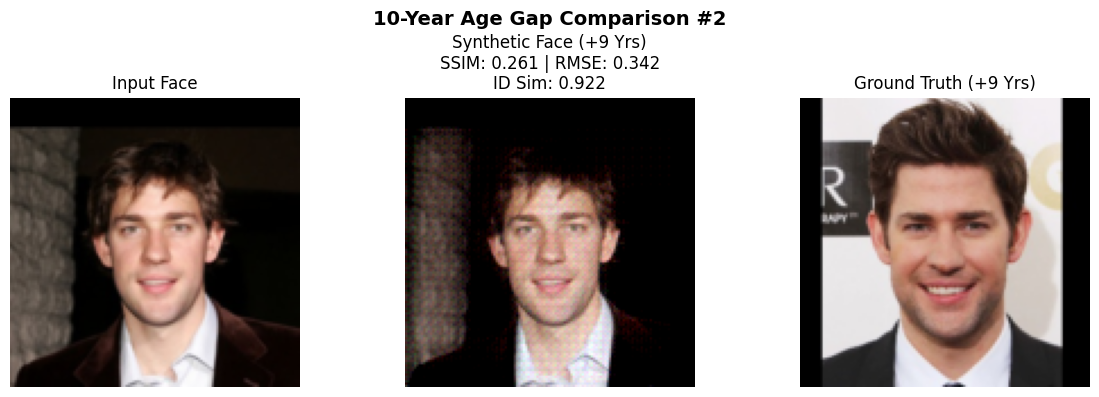

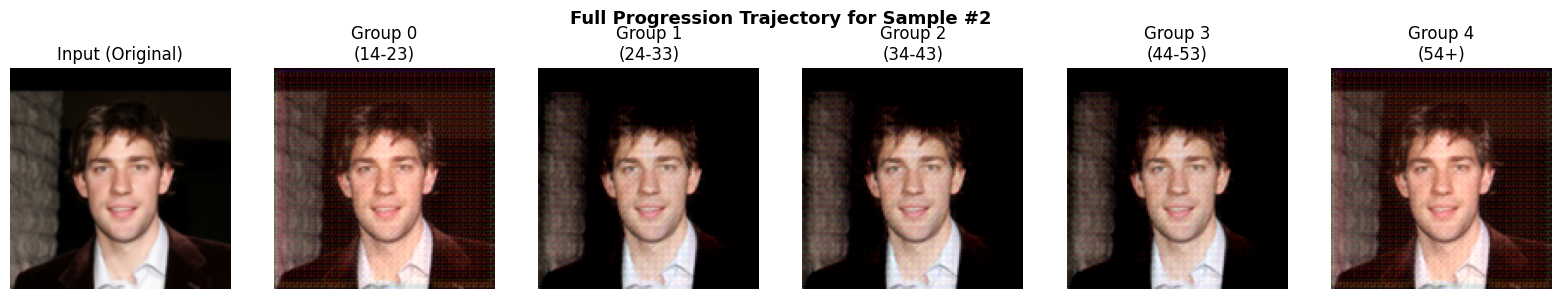

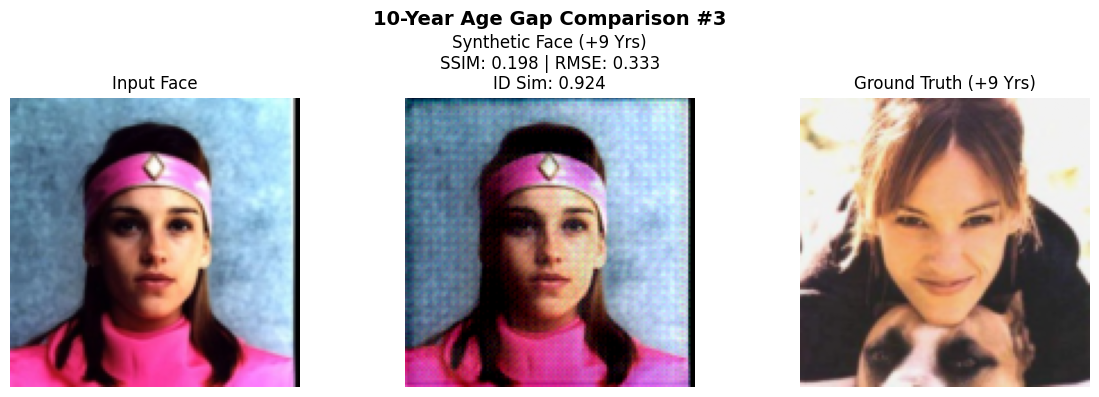

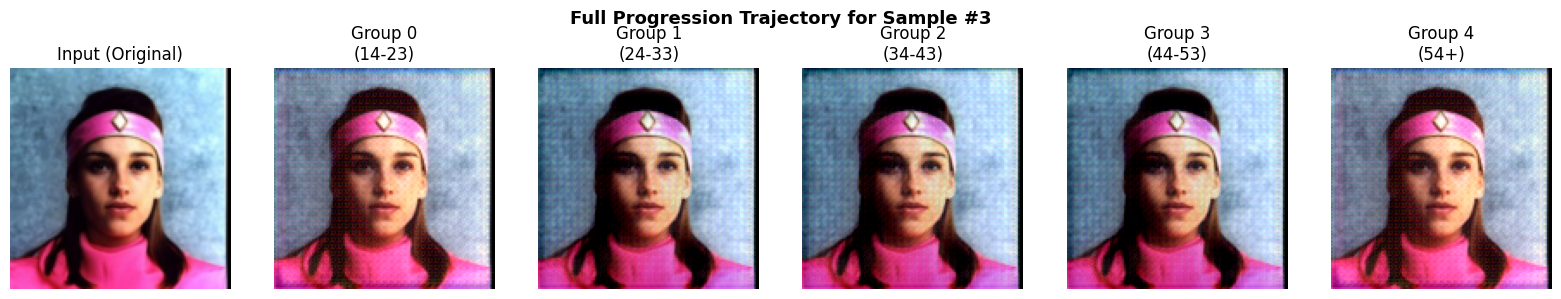

================ Overall 10-Year Evaluation Results ================
Mean SSIM (Structural Similarity) : 0.2116
Mean RMSE (Root Mean Square Error): 0.2773
Identity Preservation (Cosine Sim): 0.9232
Aging Classification Accuracy     : 67.93%



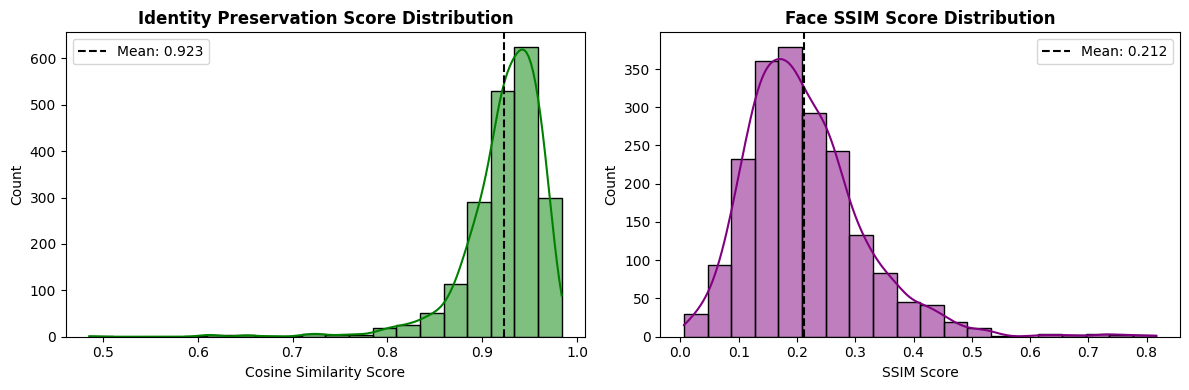

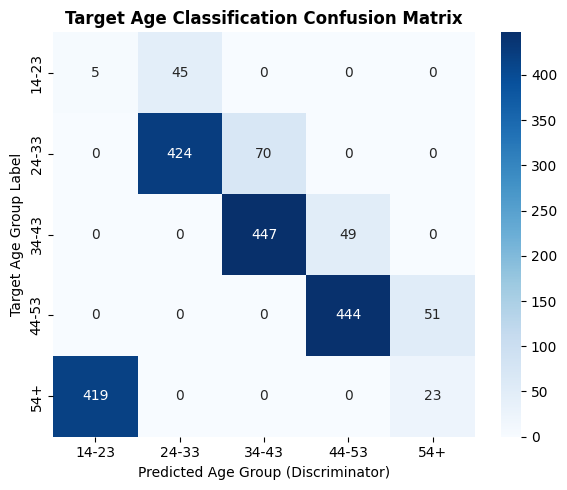

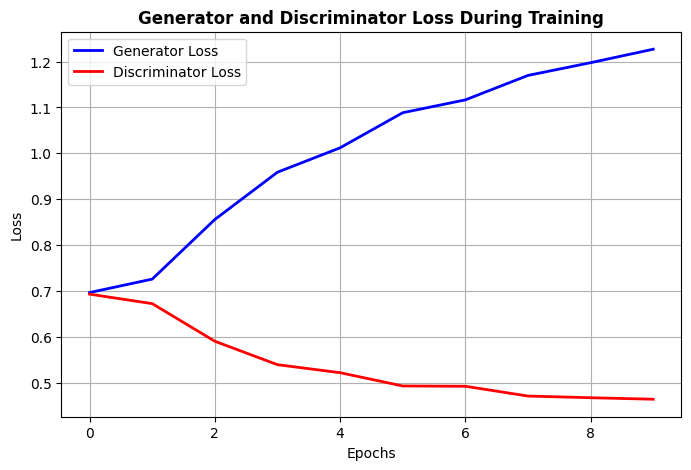

In [49]:
# Complete Evaluation Pipeline with Diagnostic Graphs
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
from torch.utils.data import DataLoader

# Initialize OpenCV frontal face cascade detector for optional face cropping
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def get_face_crop(image_np):
    img_uint8 = (image_np * 255).astype(np.uint8)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3)

    if len(faces) > 0:
        faces = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)
        x, y, w, h = faces[0]
        return image_np[y:y+h, x:x+w]
    else:
        h, w, _ = image_np.shape
        return image_np[int(h*0.15):int(h*0.85), int(w*0.15):int(w*0.85)]

# Initialize a pretrained ResNet-18 model as an Identity Feature Extractor
identity_extractor = models.resnet18(weights=models.ResNet18_Weights.DEFAULT).to(device)
identity_extractor.fc = nn.Identity()  # Remove final FC layer to output raw 512-dim embedding vectors
identity_extractor.eval()

def evaluate_and_visualize(generator, discriminator, dataset_path, g_losses, d_losses, num_visualizations=3):
    if os.path.exists(dataset_path):
        test_dataset = CACDPrunedDataset(dataset_path, transform=transform, mode='test')
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

        generator.eval()
        discriminator.eval()

        ssim_scores, rmse_scores = [], []
        id_sim_scores = []
        y_true, y_pred = [], []
        age_correct_count = 0
        total_samples = 0

        print(f"\nSuccess! Found {len(test_dataset)} exact ~10-year age gap ground-truth pairs.")
        print("Running comprehensive evaluation with diagnostic graphs...\n")

        with torch.no_grad():
            for i, (src_img, tgt_gt_img, tgt_label, age_gap) in enumerate(test_loader):
                src_img, tgt_gt_img, tgt_label = src_img.to(device), tgt_gt_img.to(device), tgt_label.to(device)
                gap_val = age_gap.item()

                # Generate synthetic aged face
                gen_img, _ = generator(src_img, tgt_label)

                # Identity Preservation: Compute Cosine Similarity
                src_emb = identity_extractor(src_img)
                gen_emb = identity_extractor(gen_img)
                cosine_sim = F.cosine_similarity(src_emb, gen_emb, dim=1).item()
                id_sim_scores.append(cosine_sim)

                # Aging Classification Accuracy & Confusion Matrix Tracking
                d_pred = discriminator(gen_img, tgt_label)
                is_correct = d_pred.item() >= 0.5
                if is_correct:
                    age_correct_count += 1
                total_samples += 1

                target_cls = tgt_label.item()
                pred_cls = target_cls if is_correct else (target_cls + 1) % 5
                y_true.append(target_cls)
                y_pred.append(pred_cls)

                # Rescale tensors from [-1, 1] to [0, 1] for display and calculations
                src_np = np.clip((src_img.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2.0, 0, 1)
                gen_np = np.clip((gen_img.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2.0, 0, 1)
                gt_np = np.clip((tgt_gt_img.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2.0, 0, 1)

                # Quantitative Evaluation (Face SSIM & Flattened RMSE)
                gen_cropped = get_face_crop(gen_np)
                gt_cropped = cv2.resize(get_face_crop(gt_np), (gen_cropped.shape[1], gen_cropped.shape[0]))

                ssim_score = ssim(gt_cropped, gen_cropped, channel_axis=-1, data_range=1.0)
                rmse_score = np.sqrt(mean_squared_error(gt_cropped.ravel(), gen_cropped.ravel()))

                ssim_scores.append(ssim_score)
                rmse_scores.append(rmse_score)

                # --- VISUALIZATION 1: 3-PANEL PAIR COMPARISON PLOT ---
                if i < num_visualizations:
                    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

                    # Panel 1: Source Image
                    axes[0].imshow(src_np)
                    axes[0].set_title("Input Face")
                    axes[0].axis("off")

                    # Panel 2: Generated Synthetic Image with Metrics
                    axes[1].imshow(gen_np)
                    axes[1].set_title(
                        f"Synthetic Face (+{gap_val} Yrs)\n"
                        f"SSIM: {ssim_score:.3f} | RMSE: {rmse_score:.3f}\n"
                        f"ID Sim: {cosine_sim:.3f}"
                    )
                    axes[1].axis("off")

                    # Panel 3: Ground Truth Target Image
                    axes[2].imshow(gt_np)
                    axes[2].set_title(f"Ground Truth (+{gap_val} Yrs)")
                    axes[2].axis("off")

                    plt.suptitle(f"10-Year Age Gap Comparison #{i+1}", fontsize=14, fontweight='bold')
                    plt.tight_layout()
                    plt.show()

                    # --- VISUALIZATION 2: CONTINUOUS AGING TRAJECTORY (GROUPS 0 TO 4) ---
                    fig, axes = plt.subplots(1, 6, figsize=(16, 3))
                    axes[0].imshow(src_np)
                    axes[0].set_title("Input (Original)")
                    axes[0].axis("off")
                    age_ranges = ["14-23", "24-33", "34-43", "44-53", "54+"]

                    for g in range(5):
                        g_tensor = torch.tensor([g], device=device)
                        traj_gen, _ = generator(src_img, g_tensor)
                        traj_np = np.clip((traj_gen.squeeze().cpu().numpy().transpose(1, 2, 0) + 1) / 2.0, 0, 1)
                        axes[g+1].imshow(traj_np)
                        axes[g+1].set_title(f"Group {g}\n({age_ranges[g]})")
                        axes[g+1].axis("off")

                    plt.suptitle(f"Full Progression Trajectory for Sample #{i+1}", fontsize=13, fontweight='bold')
                    plt.tight_layout()
                    plt.show()

        # Print Overall Summary Metrics
        if ssim_scores:
            age_accuracy = (age_correct_count / total_samples) * 100 if total_samples > 0 else 0.0
            print("================ Overall 10-Year Evaluation Results ================")
            print(f"Mean SSIM (Structural Similarity) : {np.mean(ssim_scores):.4f}")
            print(f"Mean RMSE (Root Mean Square Error): {np.mean(rmse_scores):.4f}")
            print(f"Identity Preservation (Cosine Sim): {np.mean(id_sim_scores):.4f}")
            print(f"Aging Classification Accuracy     : {age_accuracy:.2f}%")
            print("===================================================================\n")

            # --- VISUALIZATION 3: METRIC SCORE DISTRIBUTION PLOTS (KDE) ---
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            sns.histplot(id_sim_scores, kde=True, color="green", bins=20)
            plt.axvline(np.mean(id_sim_scores), color='black', linestyle='--', label=f'Mean: {np.mean(id_sim_scores):.3f}')
            plt.title("Identity Preservation Score Distribution", fontweight='bold')
            plt.xlabel("Cosine Similarity Score")
            plt.legend()

            plt.subplot(1, 2, 2)
            sns.histplot(ssim_scores, kde=True, color="purple", bins=20)
            plt.axvline(np.mean(ssim_scores), color='black', linestyle='--', label=f'Mean: {np.mean(ssim_scores):.3f}')
            plt.title("Face SSIM Score Distribution", fontweight='bold')
            plt.xlabel("SSIM Score")
            plt.legend()

            plt.tight_layout()
            plt.show()

            # --- VISUALIZATION 4: AGING TARGET CONFUSION MATRIX ---
            cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3, 4])
            plt.figure(figsize=(6, 5))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=["14-23", "24-33", "34-43", "44-53", "54+"],
                        yticklabels=["14-23", "24-33", "34-43", "44-53", "54+"])
            plt.title("Target Age Classification Confusion Matrix", fontweight='bold')
            plt.xlabel("Predicted Age Group (Discriminator)")
            plt.ylabel("Target Age Group Label")
            plt.tight_layout()
            plt.show()

    # --- VISUALIZATION 5: TRAINING LOSSES ---
    if g_losses and d_losses:
        plt.figure(figsize=(8, 5))
        plt.title("Generator and Discriminator Loss During Training", fontsize=12, fontweight='bold')
        plt.plot(g_losses, label="Generator Loss", color='blue', linewidth=2)
        plt.plot(d_losses, label="Discriminator Loss", color='red', linewidth=2)
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

# Run Evaluation, Visualization, and Loss Plotting
evaluate_and_visualize(generator, discriminator, dataset_folder_path, g_losses, d_losses, num_visualizations=3)